In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
model_comp_path = os.path.join('outputs', 'results', 'model_comparison.csv')

model_comp_df = pd.read_csv(model_comp_path)

model_comp_df.head()

,model,accuracy,precision,recall,f1_score
0,Random Forest,0.949239,0.957296,0.949239,0.950502
1,Gradient Boosting,0.954315,0.960946,0.954315,0.955184


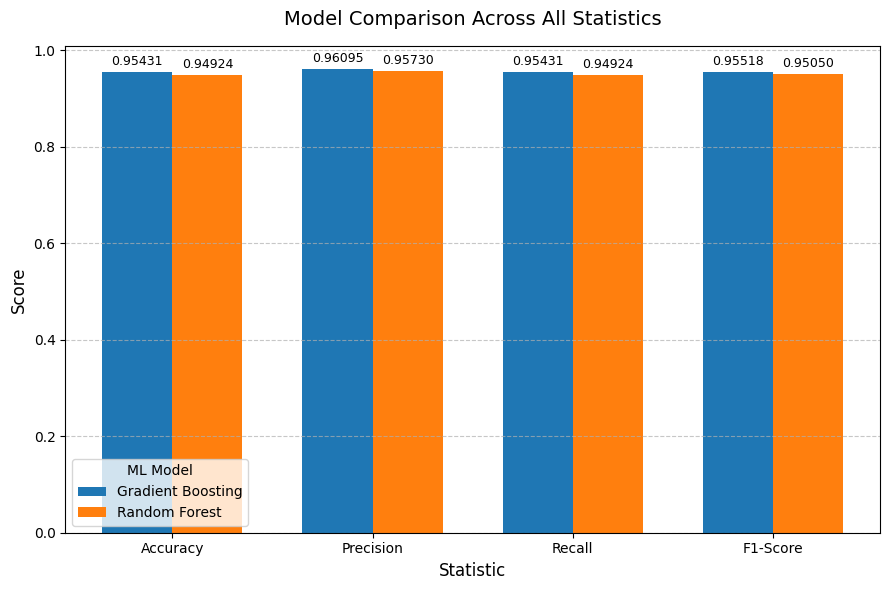

In [3]:
# Set up the statistics and the X-axis positions
stats = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(stats))
width = 0.35               # Width of each individual bar

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create the plot using subplots (Same as before)
fig, ax = plt.subplots(figsize=(9, 6))

# Extract the values for each model matching your hue_order
gb_values = model_comp_df[model_comp_df['model'] == 'Gradient Boosting'][stats].values.flatten()
rf_values = model_comp_df[model_comp_df['model'] == 'Random Forest'][stats].values.flatten()

# Plot each model side-by-side using an offset on the X-axis
rects1 = ax.bar(x - width/2, gb_values, width, label='Gradient Boosting')
rects2 = ax.bar(x + width/2, rf_values, width, label='Random Forest')

ax.bar_label(rects1, fmt='%.5f', padding=3, fontsize=9)
ax.bar_label(rects2, fmt='%.5f', padding=3, fontsize=9)

# Customize and refine chart details (90% identical to your code!)
ax.set_title('Model Comparison Across All Statistics', fontsize=14, pad=15)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Statistic', fontsize=12)

# Set the X ticks to point to the middle of the bar groups and label them
ax.set_xticks(x)
ax.set_xticklabels(labels)

# ax.set_ylim(0.90, 1.00)  # Adjusting y-limits to highlight performance differences
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='ML Model')  # Adds the legend block

# Save the plot without using plt.show() (Same as before)
plt.tight_layout()
plt.savefig('outputs/plots/model_comparison_grouped.png', dpi=300)
# plt.savefig('outputs/plots/model_comparison_grouped_sorted_.png', dpi=300)

In [5]:
model_comp_path = os.path.join('outputs', 'results', 'model_comparison_dl.csv')

model_comp_df = pd.read_csv(model_comp_path)

model_comp_df.head()

,model,model_type,accuracy,precision,recall,f1_score
0,ResNet18,CNN,0.8934,0.8978,0.8934,0.8949
1,ResNet50,CNN,0.9036,0.9149,0.9036,0.9062
2,VGG16,CNN,0.8985,0.9059,0.8985,0.9000
3,ViT-B/16,ViT,0.9036,0.9103,0.9036,0.9056
4,Swin-T,ViT,0.9086,0.9138,0.9086,0.9102


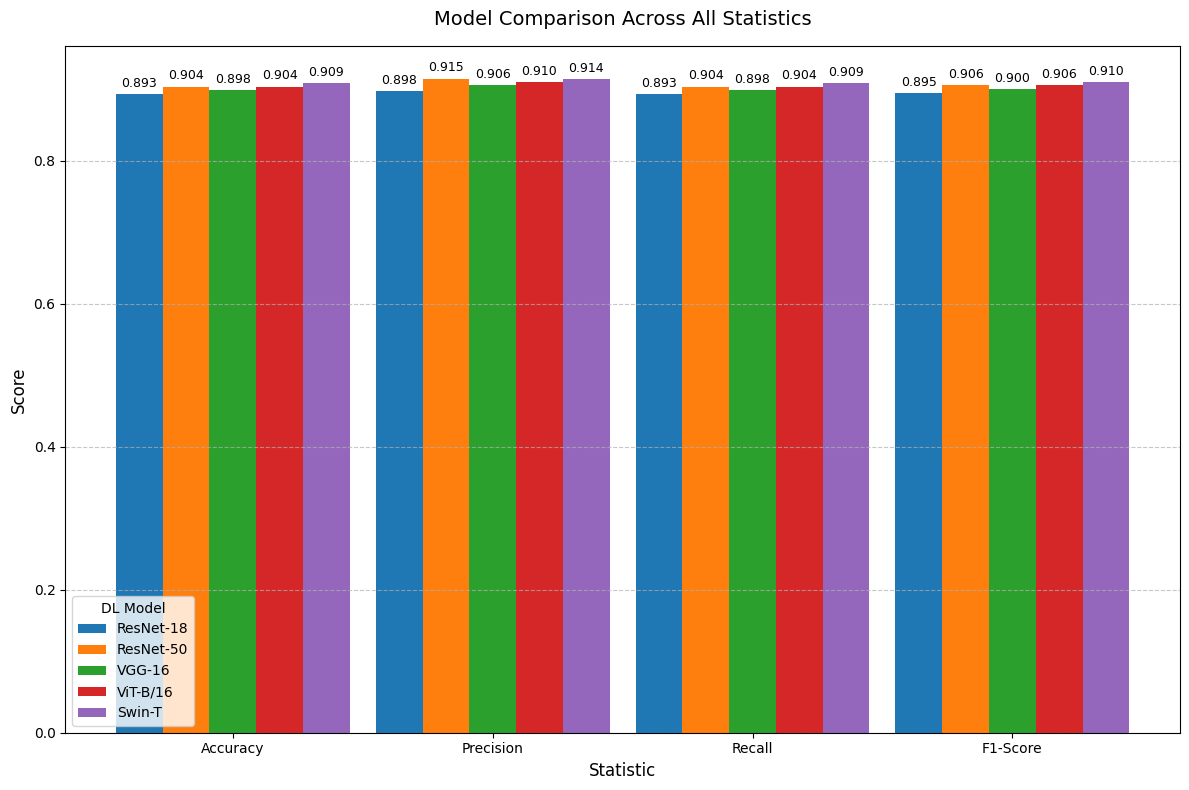

In [6]:
# Set up the statistics and the X-axis positions
stats = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(stats))
total_width = 0.9
num_models = 5
width = total_width / num_models

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create the plot using subplots (Same as before)
fig, ax = plt.subplots(figsize=(12, 8))

rn18_values = model_comp_df[model_comp_df['model'] == 'ResNet18'][stats].values.flatten()
rn50_values = model_comp_df[model_comp_df['model'] == 'ResNet50'][stats].values.flatten()
vgg16_values = model_comp_df[model_comp_df['model'] == 'VGG16'][stats].values.flatten()
vitb16_values = model_comp_df[model_comp_df['model'] == 'ViT-B/16'][stats].values.flatten()
swint_values = model_comp_df[model_comp_df['model'] == 'Swin-T'][stats].values.flatten()

# Plot each model side-by-side using an offset on the X-axis
rects1 = ax.bar(x - 2*width, rn18_values, width, label='ResNet-18')
rects2 = ax.bar(x - width, rn50_values, width, label='ResNet-50')
rects3 = ax.bar(x, vgg16_values, width, label='VGG-16')
rects4 = ax.bar(x + width, vitb16_values, width, label='ViT-B/16')
rects5 = ax.bar(x + 2*width, swint_values, width, label='Swin-T')

ax.bar_label(rects1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(rects2, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(rects3, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(rects4, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(rects5, fmt='%.3f', padding=3, fontsize=9)

# Customize and refine chart details (90% identical to your code!)
ax.set_title('Model Comparison Across All Statistics', fontsize=14, pad=15)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Statistic', fontsize=12)

# Set the X ticks to point to the middle of the bar groups and label them
ax.set_xticks(x)
ax.set_xticklabels(labels)

# ax.set_ylim(0.90, 1.00)  # Adjusting y-limits to highlight performance differences
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='DL Model')  # Adds the legend block

# Save the plot without using plt.show() (Same as before)
plt.tight_layout()
plt.savefig('outputs/plots/model_comparison_grouped_dl.png', dpi=300)

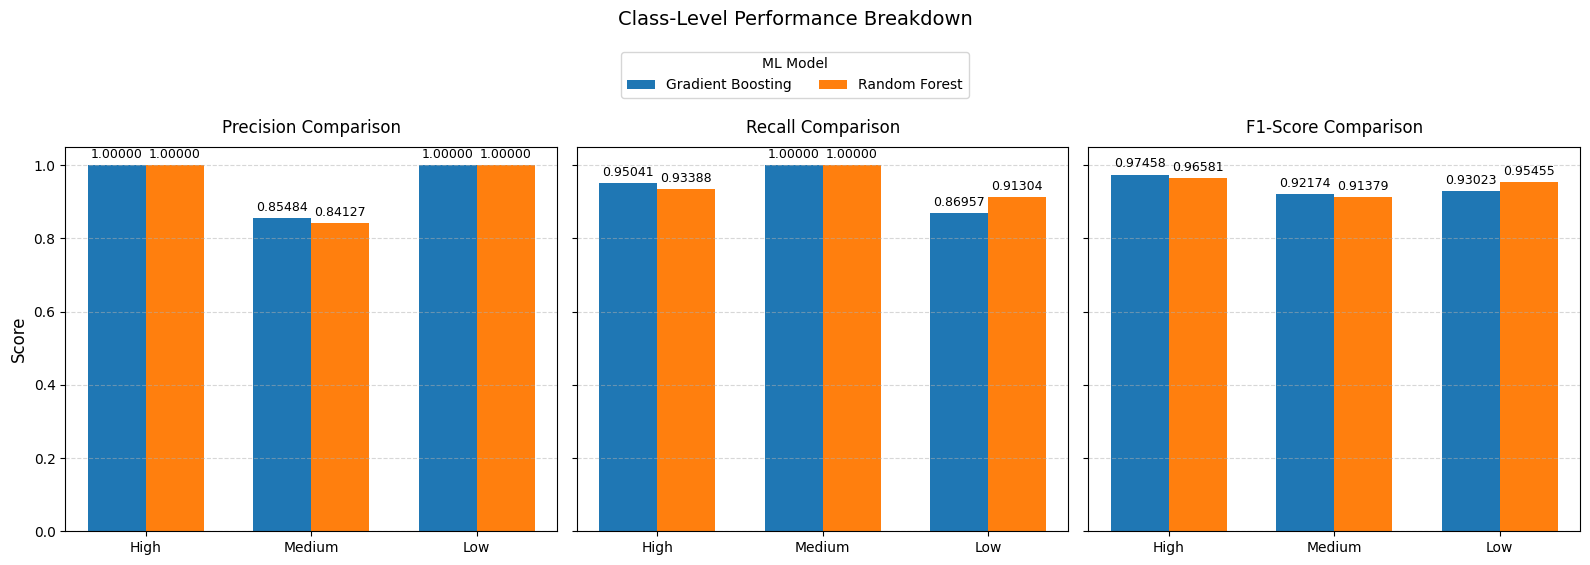

In [4]:
# Load the classification reports
gb_df = pd.read_csv(os.path.join('outputs', 'results', 'gb_class_report.csv'), index_col=0)
rf_df = pd.read_csv(os.path.join('outputs', 'results', 'rf_class_report.csv'), index_col=0)

# Filter for just the actual classes (0, 1, 2) as strings to match index
classes = ['0', '1', '2']
gb_filtered = gb_df.loc[classes]
rf_filtered = rf_df.loc[classes]

# Set up metrics and plot structure
metrics = ['precision', 'recall', 'f1-score']
labels = ['High', 'Medium', 'Low']
metric_labels = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(classes))  # [0, 1, 2] positions for classes
width = 0.35                 # Width of bars

# Create 3 subplots side-by-side (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# 3. Loop through metrics to build each subplot
for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Extract values for the current metric across classes 0, 1, 2
    gb_values = gb_filtered[metric].values
    rf_values = rf_filtered[metric].values
    
    # Plot bars side-by-side
    rects1 = ax.bar(x - width/2, gb_values, width, label='Gradient Boosting')
    rects2 = ax.bar(x + width/2, rf_values, width, label='Random Forest')
    
    # Add data labels on top of bars
    ax.bar_label(rects1, fmt='%.5f', padding=3, fontsize=9)
    ax.bar_label(rects2, fmt='%.5f', padding=3, fontsize=9)
    
    # Titles & Labels
    ax.set_title(f'{metric_labels[i]} Comparison', fontsize=12, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Global configurations for the whole figure
axes[0].set_ylabel('Score', fontsize=12)
handles, fig_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, fig_labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, title='ML Model')

plt.suptitle('Class-Level Performance Breakdown', fontsize=14, y=1.12)
plt.tight_layout()

# Save the plot
plt.savefig('outputs/plots/model_comparison_per_class.png', dpi=300, bbox_inches='tight')

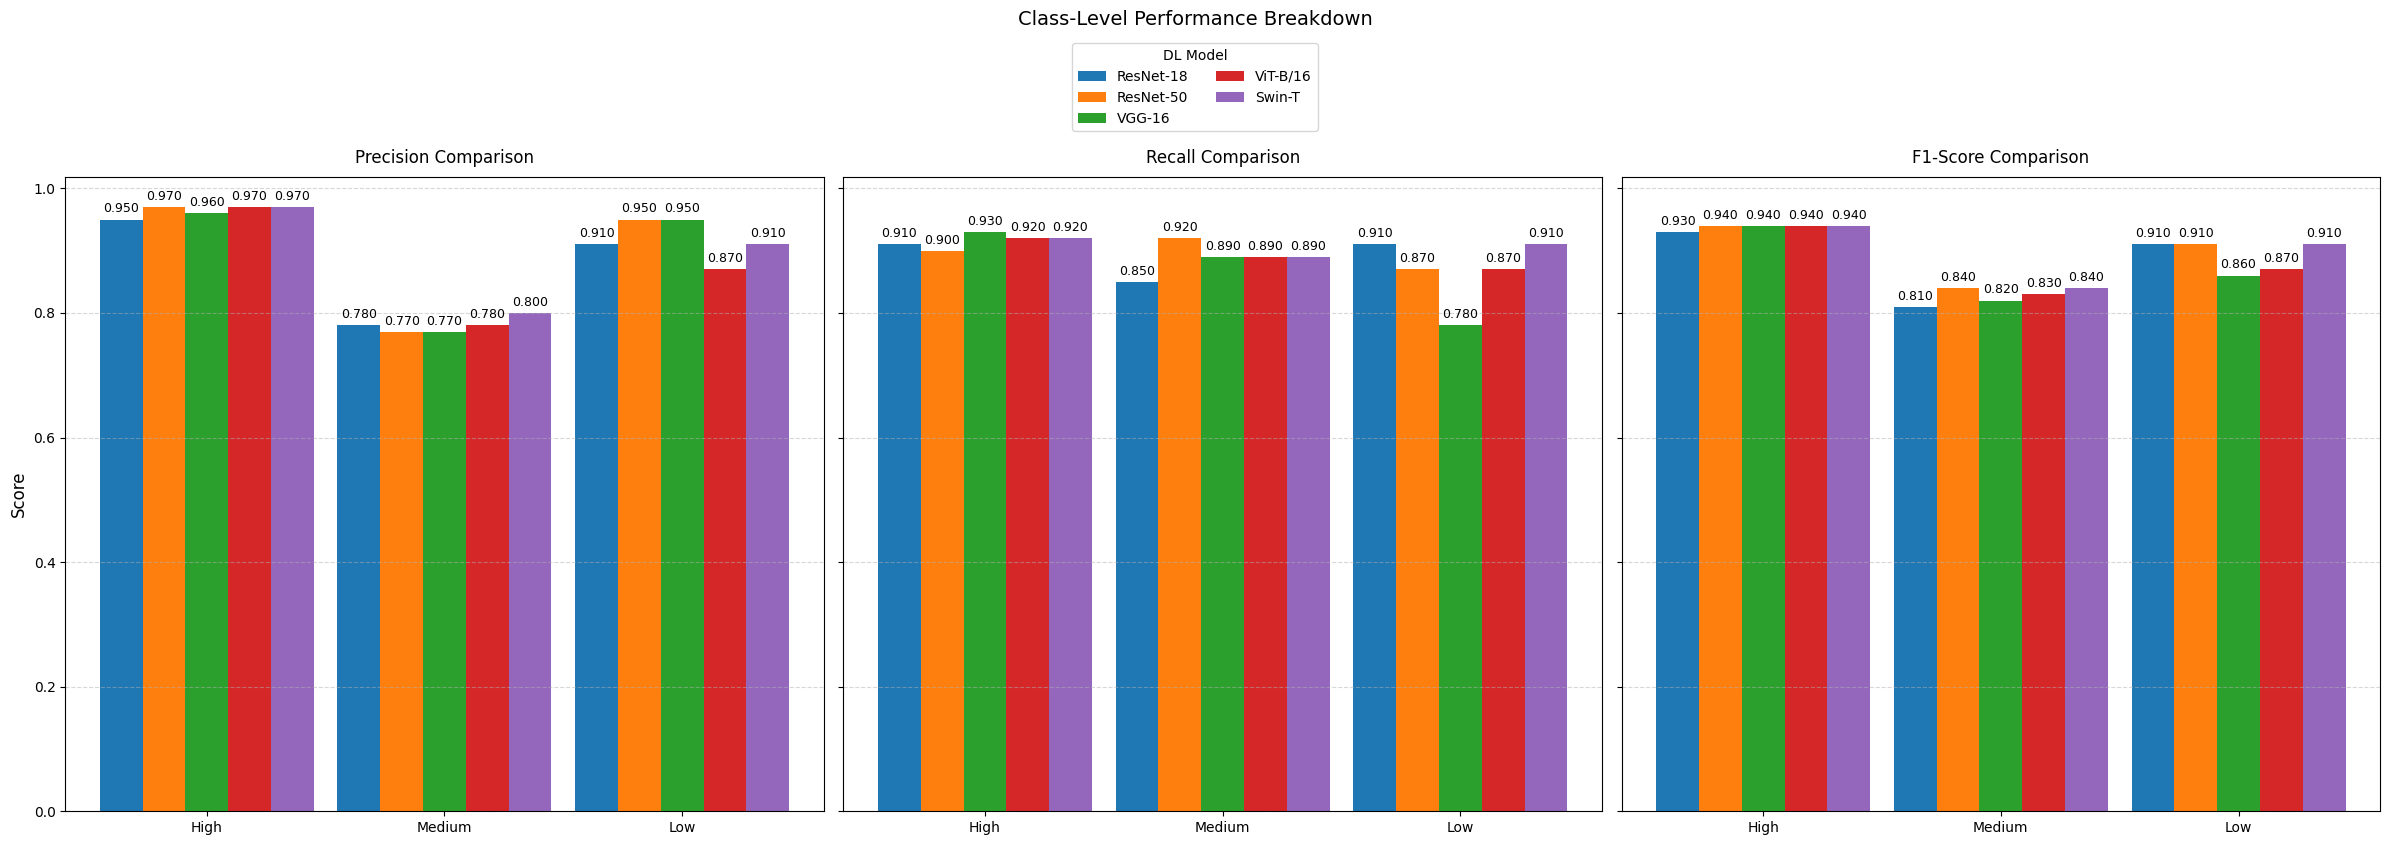

In [8]:
# Load the classification reports
resnet18_class_df = pd.read_csv(os.path.join('outputs', 'results', 'cnn_resnet18_class_report.csv'), index_col=0)
resnet50_class_df = pd.read_csv(os.path.join('outputs', 'results', 'cnn_resnet50_class_report.csv'), index_col=0)
vgg16_class_df = pd.read_csv(os.path.join('outputs', 'results', 'cnn_vgg16_class_report.csv'), index_col=0)
vitb16_class_df = pd.read_csv(os.path.join('outputs', 'results', 'vit_b_16_class_report.csv'), index_col=0)
swint_class_df = pd.read_csv(os.path.join('outputs', 'results', 'vit_swin_t_class_report.csv'), index_col=0)

# Filter for just the actual classes (0, 1, 2) as strings to match index
classes = ['0', '1', '2']
resnet18_filtered = resnet18_class_df.loc[classes]
resnet50_filtered = resnet50_class_df.loc[classes]
vgg16_filtered = vgg16_class_df.loc[classes]
vitb16_filtered = vitb16_class_df.loc[classes]
swint_filtered = swint_class_df.loc[classes]

# Set up metrics and plot structure
metrics = ['precision', 'recall', 'f1-score']
labels = ['High', 'Medium', 'Low']
metric_labels = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(classes)) 
total_width = 0.9
num_models = 5
width = total_width / num_models

# Create 3 subplots side-by-side (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(24, 7.5), sharey=True)

# Loop through metrics to build each subplot
for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Extract values for the current metric across classes 0, 1, 2
    rn18_values = resnet18_filtered[metric].values
    rn50_values = resnet50_filtered[metric].values
    vgg16_values = vgg16_filtered[metric].values
    vitb16_values = vitb16_filtered[metric].values
    swint_values = swint_filtered[metric].values
    
    # Plot bars side-by-side
    rects1 = ax.bar(x - 2*width, rn18_values, width, label='ResNet-18')
    rects2 = ax.bar(x - width, rn50_values, width, label='ResNet-50')
    rects3 = ax.bar(x, vgg16_values, width, label='VGG-16')
    rects4 = ax.bar(x + width, vitb16_values, width, label='ViT-B/16')
    rects5 = ax.bar(x + 2*width, swint_values, width, label='Swin-T')
    
    # Add data labels on top of bars
    ax.bar_label(rects1, fmt='%.3f', padding=3, fontsize=9)
    ax.bar_label(rects2, fmt='%.3f', padding=3, fontsize=9)
    ax.bar_label(rects3, fmt='%.3f', padding=3, fontsize=9)
    ax.bar_label(rects4, fmt='%.3f', padding=3, fontsize=9)
    ax.bar_label(rects5, fmt='%.3f', padding=3, fontsize=9)
    
    # Titles & Labels
    ax.set_title(f'{metric_labels[i]} Comparison', fontsize=12, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Global configurations for the whole figure
axes[0].set_ylabel('Score', fontsize=12)
handles, fig_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, fig_labels, loc='upper center', bbox_to_anchor=(0.5, 1.085), ncol=2, title='DL Model')

plt.suptitle('Class-Level Performance Breakdown', fontsize=14, y=1.12)
plt.tight_layout()

# Save the plot
plt.savefig('outputs/plots/model_comparison_per_class_dl.png', dpi=300, bbox_inches='tight')